In [1]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,_),(_,_) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train.astype('float32')/255.0 

X_train = np.reshape(X_train, (-1,28,28,1))

### Generator

In [3]:
latent_dim = 100 

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28,1))
])

generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12928     
                                                                 
 dense_1 (Dense)             (None, 784)               101136    
                                                                 
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
Total params: 114,064
Trainable params: 114,064
Non-trainable params: 0
_________________________________________________________________


### Discriminator

In [4]:
discriminator = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 100,609
Trainable params: 100,609
Non-trainable params: 0
_________________________________________________________________


In [5]:
discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
    )

### Combine Generator + Discriminator

In [6]:
discriminator.trainable = False 

gan_input = keras.Input(shape=(latent_dim))

fake_image = generator(gan_input)

gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output) 

gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)

gan.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 100)]             0         
                                                                 
 sequential (Sequential)     (None, 28, 28, 1)         114064    
                                                                 
 sequential_1 (Sequential)   (None, 1)                 100609    
                                                                 
Total params: 214,673
Trainable params: 114,064
Non-trainable params: 100,609
_________________________________________________________________


### Train GAN

In [8]:
epochs = 5000
batch_size = 128

for epoch in range(epochs):
    #Train Discriminator
    idx = np.random.randint(0,X_train.shape[0],batch_size)
    real_images = X_train[idx] 

    noise = np.random.normal(0,1, (batch_size, latent_dim))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

    #Train Generator
    noise = np.random.normal(0,1, (batch_size,latent_dim))

    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1))) 

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch} |"
              f"D_Loss: {d_loss_real[0]:.4f} |"
              f"G_Loss: {g_loss[0]:.4f} |"
              )

Epoch: 0 |D_Loss: 0.2891 |G_Loss: 1.8313 |
Epoch: 1000 |D_Loss: 0.1770 |G_Loss: 2.0764 |
Epoch: 2000 |D_Loss: 0.0944 |G_Loss: 2.9931 |
Epoch: 3000 |D_Loss: 0.1457 |G_Loss: 2.6209 |
Epoch: 4000 |D_Loss: 0.2799 |G_Loss: 2.0290 |


### Generate Images

In [9]:
noise = np.random.normal(0,1, (10,latent_dim))

generated_images = generator.predict(noise, verbose=0)

### Display generated Images

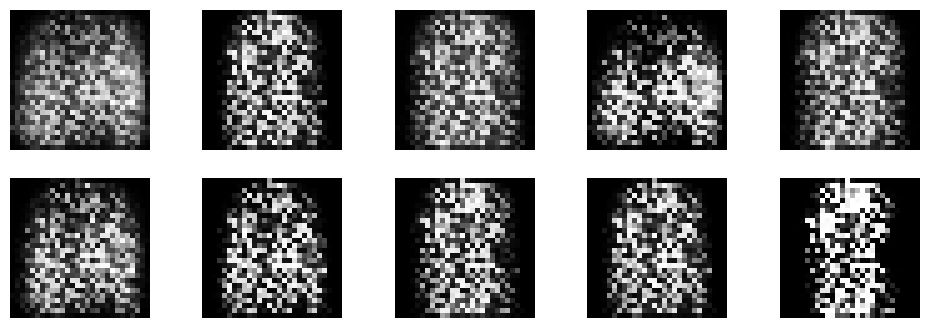

In [13]:
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

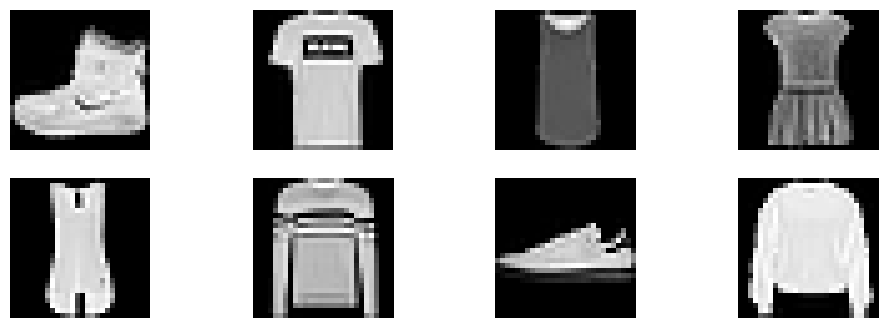

In [12]:
plt.figure(figsize=(12, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()